# EEG Feature Comparison with Multimodal Late Fusion

This notebook compares three EEG feature extraction approaches **in full multimodal late fusion**:
1. **Regional averages only** (16 features: 4 bands × 4 regions)
2. **Regional + Individual channels** (96 features: 16 regional + 80 channels)
3. **Non-temporal features** (~96 features: power + temporal dynamics + lateralization)

For each EEG feature set, we:
- Evaluate EEG features alone (single modality)
- Run full late fusion with physiology, behavior, gaze, and EEG
- Compare overall fusion accuracy and modality contributions

Goal: Determine which EEG feature approach contributes most to multimodal decision prediction.

In [1]:
# ============================================================================
# CONFIGURATION
# ============================================================================
TIMEFRAME = 'PRE'  # Fixed to PRE - EEG is from display/decision phase
# ============================================================================

import sys
sys.path.append('../..')

import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from src.utils.io import load_features, save_results
from src.utils.config import get_model_params
from src.utils.validation import validate_modality_features
from src.models.fusion import weighted_late_fusion
from src.visualization.plots import set_style, plot_method_comparison, plot_modality_weights

np.random.seed(42)
set_style('whitegrid')

print(f"\n{'='*70}")
print(f"EEG FEATURE COMPARISON WITH MULTIMODAL LATE FUSION ({TIMEFRAME})")
print(f"{'='*70}\n")


EEG FEATURE COMPARISON WITH MULTIMODAL LATE FUSION (PRE)



## 1. Load Base Features (Physio, Behavior, Gaze)

In [2]:
# Load base features (physio, behavior, gaze)
features_path = f'../../data/results/features_{TIMEFRAME}/extracted_features_{TIMEFRAME}.pkl'
feature_data = load_features(features_path, timeframe=TIMEFRAME)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

print(f"Loaded {len(merged_df)} trials from {merged_df['subject_id'].nunique()} subjects")
print(f"\nFeature counts:")
print(f"  Physiology: {len(physio_cols)} features")
print(f"  Behavior:   {len(behavior_cols)} features")
print(f"  Gaze:       {len(gaze_cols)} features")

Loaded 12511 trials from 97 subjects

Feature counts:
  Physiology: 13 features
  Behavior:   7 features
  Gaze:       20 features


## 2. Load All EEG Feature Sets

In [3]:
# Load all three EEG feature sets
eeg_datasets = {}

# 1. Regional only (original)
try:
    with open('../../data/results/eeg_features.pkl', 'rb') as f:
        data = pickle.load(f)
        eeg_datasets['Regional'] = {
            'df': data['eeg_features_df'],
            'cols': data['feature_columns'],
            'n_features': len(data['feature_columns'])
        }
    print(f"✓ Loaded Regional features: {eeg_datasets['Regional']['n_features']} features")
except FileNotFoundError:
    print("✗ Regional features not found - run extract_eeg_features.py")

# 2. Regional + Individual channels
try:
    with open('../../data/results/eeg_features_with_channels.pkl', 'rb') as f:
        data = pickle.load(f)
        eeg_datasets['Regional+Channels'] = {
            'df': data['eeg_features_df'],
            'cols': data['feature_columns'],
            'n_features': len(data['feature_columns'])
        }
    print(f"✓ Loaded Regional+Channels features: {eeg_datasets['Regional+Channels']['n_features']} features")
except FileNotFoundError:
    print("✗ Regional+Channels features not found - run extract_eeg_features_with_channels.py")

# 3. Non-temporal
try:
    with open('../../data/results/eeg_features_non_temporal.pkl', 'rb') as f:
        data = pickle.load(f)
        eeg_datasets['Non-temporal'] = {
            'df': data['eeg_features_df'],
            'cols': data['feature_columns'],
            'n_features': len(data['feature_columns'])
        }
    print(f"✓ Loaded Non-temporal features: {eeg_datasets['Non-temporal']['n_features']} features")
except FileNotFoundError:
    print("✗ Non-temporal features not found - run extract_eeg_features_non_temporal.py")

if len(eeg_datasets) == 0:
    raise RuntimeError("No EEG features loaded. Run extraction scripts first.")

✓ Loaded Regional features: 16 features
✓ Loaded Regional+Channels features: 96 features
✓ Loaded Non-temporal features: 96 features


## 3. List All Features by Type

In [4]:
# Display all features for each EEG feature set
print(f"\n{'='*70}")
print(f"FEATURE LISTINGS BY TYPE")
print(f"{'='*70}\n")

for name, data in eeg_datasets.items():
    print(f"\n{name} Features ({len(data['cols'])} total):")
    print(f"-" * 70)
    
    # Group features by band or type
    if name == 'Regional':
        # Group by band
        bands = ['Delta', 'Theta', 'Alpha', 'Beta']
        for band in bands:
            band_feats = [f for f in data['cols'] if band in f]
            if band_feats:
                print(f"\n  {band} ({len(band_feats)} features):")
                for feat in band_feats:
                    print(f"    - {feat}")
    
    elif name == 'Regional+Channels':
        # Show regional features
        regional_feats = [f for f in data['cols'] if any(region in f for region in ['Frontal', 'Central', 'Parietal', 'Occipital'])]
        channel_feats = [f for f in data['cols'] if f not in regional_feats]
        
        print(f"\n  Regional Features ({len(regional_feats)}):")
        for feat in regional_feats[:5]:
            print(f"    - {feat}")
        if len(regional_feats) > 5:
            print(f"    ... and {len(regional_feats)-5} more")
        
        print(f"\n  Individual Channel Features ({len(channel_feats)}):")
        # Group by band
        bands = ['Delta', 'Theta', 'Alpha', 'Beta']
        for band in bands:
            band_ch_feats = [f for f in channel_feats if band in f]
            if band_ch_feats:
                print(f"    {band} ({len(band_ch_feats)} channels):", ', '.join([f.split('_')[-1] for f in band_ch_feats[:10]]))
                if len(band_ch_feats) > 10:
                    print(f"      ... and {len(band_ch_feats)-10} more")
    
    elif name == 'Non-temporal':
        # Group by feature type
        power_feats = [f for f in data['cols'] if '_power' in f]
        temporal_feats = [f for f in data['cols'] if any(x in f for x in ['_mean', '_std', '_slope'])]
        lat_feats = [f for f in data['cols'] if '_lateralization' in f]
        
        print(f"\n  Power Features ({len(power_feats)}):")
        for feat in power_feats[:5]:
            print(f"    - {feat}")
        if len(power_feats) > 5:
            print(f"    ... and {len(power_feats)-5} more")
        
        print(f"\n  Temporal Dynamics ({len(temporal_feats)}):")
        for feat in temporal_feats[:5]:
            print(f"    - {feat}")
        if len(temporal_feats) > 5:
            print(f"    ... and {len(temporal_feats)-5} more")
        
        print(f"\n  Lateralization Indices ({len(lat_feats)}):")
        for feat in lat_feats[:5]:
            print(f"    - {feat}")
        if len(lat_feats) > 5:
            print(f"    ... and {len(lat_feats)-5} more")
    
    print()


FEATURE LISTINGS BY TYPE


Regional Features (16 total):
----------------------------------------------------------------------

  Delta (4 features):
    - eeg_Delta_Frontal
    - eeg_Delta_Central
    - eeg_Delta_Parietal
    - eeg_Delta_Occipital

  Theta (4 features):
    - eeg_Theta_Frontal
    - eeg_Theta_Central
    - eeg_Theta_Parietal
    - eeg_Theta_Occipital

  Alpha (4 features):
    - eeg_Alpha_Frontal
    - eeg_Alpha_Central
    - eeg_Alpha_Parietal
    - eeg_Alpha_Occipital

  Beta (4 features):
    - eeg_Beta_Frontal
    - eeg_Beta_Central
    - eeg_Beta_Parietal
    - eeg_Beta_Occipital


Regional+Channels Features (96 total):
----------------------------------------------------------------------

  Regional Features (16):
    - eeg_Delta_Frontal
    - eeg_Delta_Central
    - eeg_Delta_Parietal
    - eeg_Delta_Occipital
    - eeg_Theta_Frontal
    ... and 11 more

  Individual Channel Features (80):
    Delta (20 channels): Fp1, F7, F8, T4, T6, T5, T3, Fp2, O1, P3
   

## 4. EEG-Only Evaluation (Single Modality)

In [5]:
def evaluate_eeg_features(merged_df, eeg_df, eeg_cols, feature_set_name):
    """
    Evaluate EEG features using LOSO cross-validation.
    """
    # Get EEG subjects and filter
    eeg_subjects = eeg_df['subject_id'].unique()
    merged_df_eeg = merged_df[merged_df['subject_id'].isin(eeg_subjects)].copy()
    
    # Merge with EEG features
    merged_df_eeg = merged_df_eeg.merge(
        eeg_df[['trial_id'] + eeg_cols],
        on='trial_id',
        how='inner'
    )
    
    print(f"\n{'='*60}")
    print(f"{feature_set_name} Feature Set (EEG Only)")
    print(f"{'='*60}")
    print(f"Subjects: {merged_df_eeg['subject_id'].nunique()}")
    print(f"Trials: {len(merged_df_eeg)}")
    print(f"Features: {len(eeg_cols)}")
    
    # Prepare data
    X = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[eeg_cols])
    y = merged_df_eeg['outcome'].values
    subjects = merged_df_eeg['subject_id'].values
    
    # LOSO cross-validation
    logo = LeaveOneGroupOut()
    model_params = get_model_params('random_forest')
    
    subject_accs = []
    subject_f1s = []
    all_importances = []
    
    for train_idx, test_idx in logo.split(X, y, subjects):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model = RandomForestClassifier(**model_params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        subject_accs.append(acc)
        subject_f1s.append(f1)
        all_importances.append(model.feature_importances_)
    
    overall_acc = np.mean(subject_accs)
    overall_f1 = np.mean(subject_f1s)
    acc_sem = stats.sem(subject_accs)
    f1_sem = stats.sem(subject_f1s)
    avg_importances = np.mean(all_importances, axis=0)
    
    print(f"\nResults:")
    print(f"  Accuracy: {overall_acc:.3f} ± {acc_sem:.3f}")
    print(f"  F1-Score: {overall_f1:.3f} ± {f1_sem:.3f}")
    
    feature_importance_df = pd.DataFrame({
        'Feature': eeg_cols,
        'Importance': avg_importances
    }).sort_values('Importance', ascending=False)
    
    print(f"\nTop 5 features:")
    for idx, row in feature_importance_df.head(5).iterrows():
        print(f"  {row['Feature']:40s} {row['Importance']:.4f}")
    
    return {
        'name': feature_set_name,
        'n_features': len(eeg_cols),
        'n_subjects': merged_df_eeg['subject_id'].nunique(),
        'n_trials': len(merged_df_eeg),
        'accuracy': overall_acc,
        'accuracy_sem': acc_sem,
        'f1': overall_f1,
        'f1_sem': f1_sem,
        'feature_importances': feature_importance_df
    }

In [6]:
# Evaluate each EEG feature set (single modality)
eeg_only_results = {}

for name, data in eeg_datasets.items():
    eeg_only_results[name] = evaluate_eeg_features(
        merged_df,
        data['df'],
        data['cols'],
        name
    )


Regional Feature Set (EEG Only)
Subjects: 82
Trials: 10431
Features: 16

Results:
  Accuracy: 0.517 ± 0.016
  F1-Score: 0.498 ± 0.017

Top 5 features:
  eeg_Beta_Central                         0.1216
  eeg_Beta_Frontal                         0.0858
  eeg_Beta_Parietal                        0.0803
  eeg_Beta_Occipital                       0.0785
  eeg_Delta_Parietal                       0.0682

Regional+Channels Feature Set (EEG Only)
Subjects: 82
Trials: 10431
Features: 96

Results:
  Accuracy: 0.507 ± 0.019
  F1-Score: 0.482 ± 0.019

Top 5 features:
  eeg_Beta_P4                              0.0396
  eeg_Beta_F7                              0.0341
  eeg_Beta_C4                              0.0326
  eeg_Beta_P3                              0.0253
  eeg_Theta_F7                             0.0224

Non-temporal Feature Set (EEG Only)
Subjects: 82
Trials: 10431
Features: 96

Results:
  Accuracy: 0.490 ± 0.017
  F1-Score: 0.473 ± 0.018

Top 5 features:
  eeg_Beta_Central_lateralizati

In [7]:
# Compare EEG-only results
eeg_only_df = pd.DataFrame([
    {
        'Feature Set': r['name'],
        'N Features': r['n_features'],
        'Accuracy': r['accuracy'],
        'Accuracy SEM': r['accuracy_sem'],
        'F1-Score': r['f1'],
        'F1 SEM': r['f1_sem']
    }
    for r in eeg_only_results.values()
])

print(f"\n{'='*70}")
print(f"EEG-ONLY COMPARISON ({TIMEFRAME})")
print(f"{'='*70}")
print(eeg_only_df.to_string(index=False))

# Best EEG-only
best_eeg = eeg_only_df.loc[eeg_only_df['Accuracy'].idxmax()]
print(f"\nBest EEG-only: {best_eeg['Feature Set']} (Acc={best_eeg['Accuracy']:.3f})")


EEG-ONLY COMPARISON (PRE)
      Feature Set  N Features  Accuracy  Accuracy SEM  F1-Score   F1 SEM
         Regional          16  0.516569      0.016078  0.497793 0.017406
Regional+Channels          96  0.507251      0.018593  0.482457 0.019446
     Non-temporal          96  0.490181      0.017128  0.473440 0.018469

Best EEG-only: Regional (Acc=0.517)


## 5. Multimodal Late Fusion with Each EEG Feature Set

In [8]:
def run_multimodal_fusion(merged_df, physio_cols, behavior_cols, gaze_cols,
                           eeg_df, eeg_cols, eeg_name):
    """
    Run full late fusion with all modalities.
    """
    print(f"\n{'='*70}")
    print(f"MULTIMODAL LATE FUSION: {eeg_name} EEG")
    print(f"{'='*70}")
    
    # Filter to EEG subjects and merge
    eeg_subjects = eeg_df['subject_id'].unique()
    merged_df_eeg = merged_df[merged_df['subject_id'].isin(eeg_subjects)].copy()
    
    merged_df_eeg = merged_df_eeg.merge(
        eeg_df[['trial_id'] + eeg_cols],
        on='trial_id',
        how='inner'
    )
    
    print(f"Subjects: {merged_df_eeg['subject_id'].nunique()}")
    print(f"Trials:   {len(merged_df_eeg)}")
    print(f"\nFeatures per modality:")
    print(f"  Physiology: {len(physio_cols)}")
    print(f"  Behavior:   {len(behavior_cols)}")
    print(f"  Gaze:       {len(gaze_cols)}")
    print(f"  EEG:        {len(eeg_cols)}")
    
    # Prepare modality arrays
    X_physio = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[physio_cols])
    X_behavior = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[behavior_cols])
    X_gaze = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[gaze_cols]) if len(gaze_cols) > 0 else np.zeros((len(merged_df_eeg), 1))
    X_eeg = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[eeg_cols])
    
    y = merged_df_eeg['outcome'].values
    subjects = merged_df_eeg['subject_id'].values
    
    # Validate and run fusion
    modality_names = ['Physiology', 'Behavior', 'Gaze', 'EEG']
    X_modalities = [X_physio, X_behavior, X_gaze, X_eeg]
    validate_modality_features(X_modalities, y, subjects, modality_names)
    
    print("\nRunning fusion methods...")
    results_weighted = weighted_late_fusion(X_modalities, y, subjects, modality_names,
                                            fusion_method='weighted')
    results_stacking = weighted_late_fusion(X_modalities, y, subjects, modality_names,
                                            fusion_method='stacking')
    
    print(f"\nFusion Results:")
    print(f"  Weighted: Acc={results_weighted['accuracy_mean']:.3f} ± {results_weighted['accuracy_sem']:.3f}, F1={results_weighted['f1_mean']:.3f}")
    print(f"  Stacking: Acc={results_stacking['accuracy_mean']:.3f} ± {results_stacking['accuracy_sem']:.3f}, F1={results_stacking['f1_mean']:.3f}")
    
    print(f"\nModality Weights (Weighted Fusion):")
    for name, w in zip(modality_names, results_weighted['weights']):
        print(f"  {name:12s}: {w*100:5.1f}%")
    
    return {
        'eeg_name': eeg_name,
        'n_eeg_features': len(eeg_cols),
        'results_weighted': results_weighted,
        'results_stacking': results_stacking,
        'modality_names': modality_names
    }

In [9]:
# Run multimodal fusion for each EEG feature set
fusion_results = {}

for eeg_name, eeg_data in eeg_datasets.items():
    fusion_results[eeg_name] = run_multimodal_fusion(
        merged_df,
        physio_cols,
        behavior_cols,
        gaze_cols,
        eeg_data['df'],
        eeg_data['cols'],
        eeg_name
    )


MULTIMODAL LATE FUSION: Regional EEG
Subjects: 82
Trials:   10431

Features per modality:
  Physiology: 13
  Behavior:   7
  Gaze:       20
  EEG:        16
✓ Modality validation passed:
  Physiology: 10431 samples × 13 features
  Behavior: 10431 samples × 7 features
  Gaze: 10431 samples × 20 features
  EEG: 10431 samples × 16 features

Running fusion methods...

Fusion Results:
  Weighted: Acc=0.698 ± 0.015, F1=0.685
  Stacking: Acc=0.631 ± 0.015, F1=0.645

Modality Weights (Weighted Fusion):
  Physiology  :   2.5%
  Behavior    :  95.8%
  Gaze        :   0.6%
  EEG         :   1.1%

MULTIMODAL LATE FUSION: Regional+Channels EEG
Subjects: 82
Trials:   10431

Features per modality:
  Physiology: 13
  Behavior:   7
  Gaze:       20
  EEG:        96
✓ Modality validation passed:
  Physiology: 10431 samples × 13 features
  Behavior: 10431 samples × 7 features
  Gaze: 10431 samples × 20 features
  EEG: 10431 samples × 96 features

Running fusion methods...

Fusion Results:
  Weighted: Ac

## 6. Compare Multimodal Fusion Results

In [10]:
# Build comparison dataframe for multimodal fusion
multimodal_comparison = []

for eeg_name, result in fusion_results.items():
    multimodal_comparison.extend([
        {
            'EEG Features': eeg_name,
            'N EEG Features': result['n_eeg_features'],
            'Method': 'Weighted',
            'Accuracy': result['results_weighted']['accuracy_mean'],
            'Accuracy SEM': result['results_weighted']['accuracy_sem'],
            'F1-Score': result['results_weighted']['f1_mean']
        },
        {
            'EEG Features': eeg_name,
            'N EEG Features': result['n_eeg_features'],
            'Method': 'Stacking',
            'Accuracy': result['results_stacking']['accuracy_mean'],
            'Accuracy SEM': result['results_stacking']['accuracy_sem'],
            'F1-Score': result['results_stacking']['f1_mean']
        }
    ])

multimodal_df = pd.DataFrame(multimodal_comparison)

print(f"\n{'='*70}")
print(f"MULTIMODAL LATE FUSION COMPARISON ({TIMEFRAME})")
print(f"{'='*70}")
print(multimodal_df.to_string(index=False))

# Find best
best_multi = multimodal_df.loc[multimodal_df['Accuracy'].idxmax()]
print(f"\n{'='*70}")
print(f"BEST MULTIMODAL CONFIGURATION:")
print(f"  EEG Features: {best_multi['EEG Features']} ({int(best_multi['N EEG Features'])} features)")
print(f"  Method: {best_multi['Method']}")
print(f"  Accuracy: {best_multi['Accuracy']:.3f} ± {best_multi['Accuracy SEM']:.3f}")
print(f"  F1-Score: {best_multi['F1-Score']:.3f}")
print(f"{'='*70}")


MULTIMODAL LATE FUSION COMPARISON (PRE)
     EEG Features  N EEG Features   Method  Accuracy  Accuracy SEM  F1-Score
         Regional              16 Weighted  0.698044      0.015032  0.684761
         Regional              16 Stacking  0.631058      0.014731  0.644629
Regional+Channels              96 Weighted  0.698694      0.014887  0.685366
Regional+Channels              96 Stacking  0.631115      0.014524  0.644499
     Non-temporal              96 Weighted  0.697649      0.014905  0.684242
     Non-temporal              96 Stacking  0.631682      0.014537  0.645279

BEST MULTIMODAL CONFIGURATION:
  EEG Features: Regional+Channels (96 features)
  Method: Weighted
  Accuracy: 0.699 ± 0.015
  F1-Score: 0.685


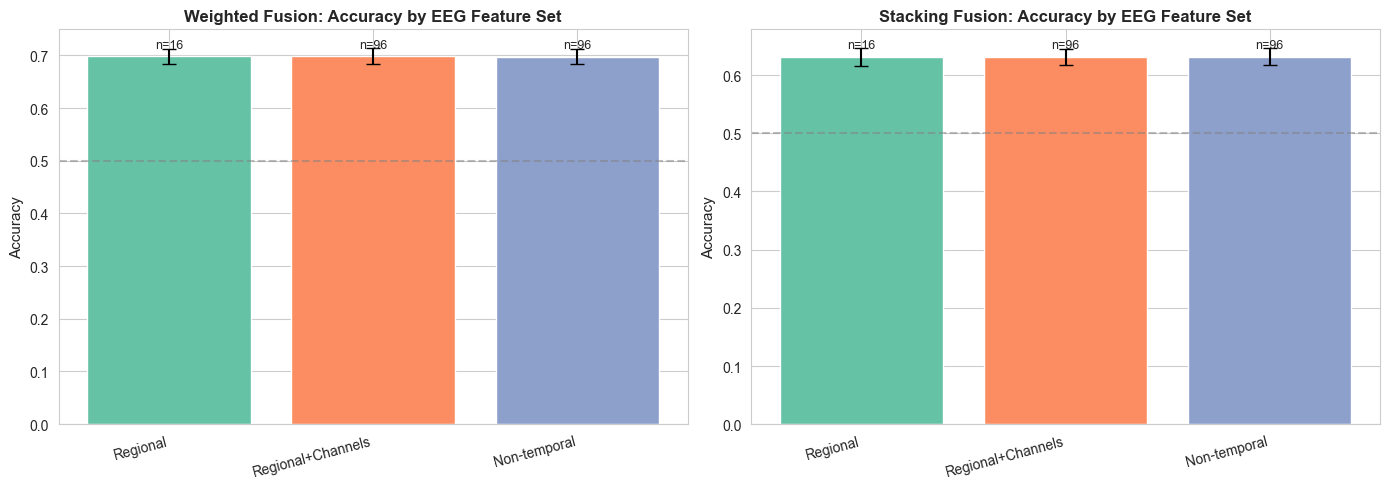

In [11]:
# Visualize multimodal comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for method_idx, method in enumerate(['Weighted', 'Stacking']):
    ax = axes[method_idx]
    method_df = multimodal_df[multimodal_df['Method'] == method]
    
    x_pos = np.arange(len(method_df))
    colors = sns.color_palette('Set2', len(method_df))
    
    ax.bar(x_pos, method_df['Accuracy'], yerr=method_df['Accuracy SEM'],
           color=colors, capsize=5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(method_df['EEG Features'], rotation=15, ha='right')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{method} Fusion: Accuracy by EEG Feature Set', fontweight='bold')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
    
    # Add feature counts as text
    for i, (idx, row) in enumerate(method_df.iterrows()):
        ax.text(i, row['Accuracy'] + 0.01, f"n={int(row['N EEG Features'])}",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Modality Contributions by EEG Feature Set

In [12]:
# Extract modality weights for weighted fusion
weights_comparison = []

for eeg_name, result in fusion_results.items():
    weights = result['results_weighted']['weights']
    modality_names = result['modality_names']
    
    for mod_name, weight in zip(modality_names, weights):
        weights_comparison.append({
            'EEG Features': eeg_name,
            'Modality': mod_name,
            'Weight': weight * 100
        })

weights_df = pd.DataFrame(weights_comparison)

print(f"\n{'='*70}")
print(f"MODALITY CONTRIBUTIONS (Weighted Fusion)")
print(f"{'='*70}")
for eeg_name in weights_df['EEG Features'].unique():
    print(f"\n{eeg_name}:")
    subset = weights_df[weights_df['EEG Features'] == eeg_name]
    for _, row in subset.iterrows():
        print(f"  {row['Modality']:12s}: {row['Weight']:5.1f}%")


MODALITY CONTRIBUTIONS (Weighted Fusion)

Regional:
  Physiology  :   2.5%
  Behavior    :  95.8%
  Gaze        :   0.6%
  EEG         :   1.1%

Regional+Channels:
  Physiology  :   2.5%
  Behavior    :  94.1%
  Gaze        :   0.5%
  EEG         :   2.8%

Non-temporal:
  Physiology  :   2.5%
  Behavior    :  95.6%
  Gaze        :   0.6%
  EEG         :   1.3%


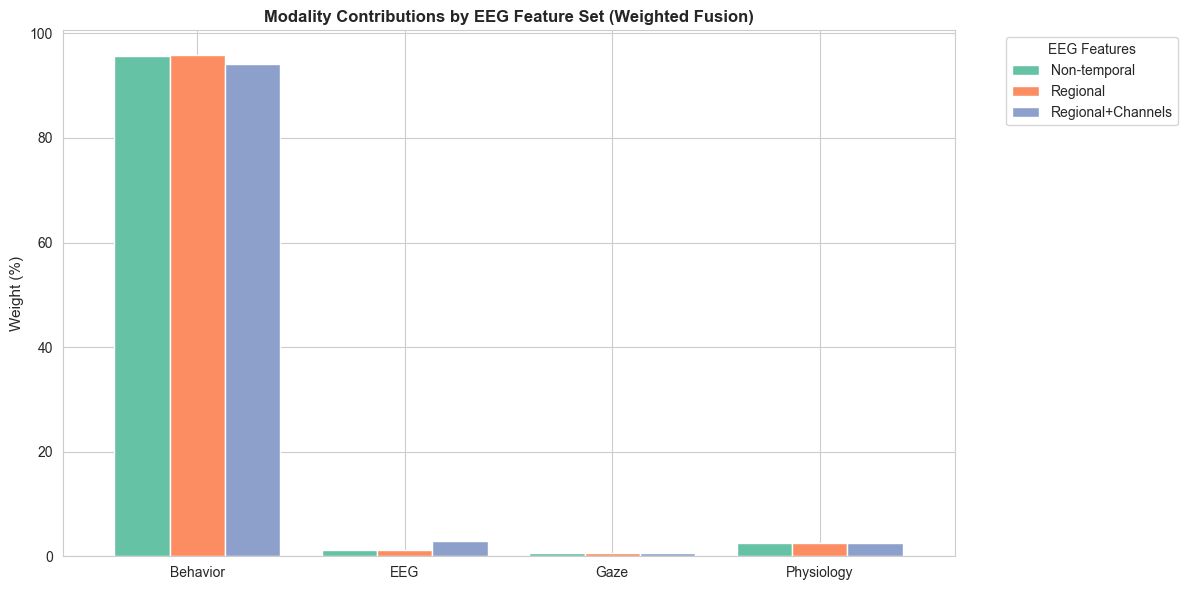


EEG MODALITY CONTRIBUTION BY FEATURE SET
     EEG Features   Weight
Regional+Channels 2.836616
     Non-temporal 1.265357
         Regional 1.125883

Best EEG contribution: Regional+Channels (2.8%)


In [13]:
# Visualize modality weights
fig, ax = plt.subplots(figsize=(12, 6))

weights_pivot = weights_df.pivot(index='Modality', columns='EEG Features', values='Weight')
weights_pivot.plot(kind='bar', ax=ax, width=0.8, color=sns.color_palette('Set2', len(fusion_results)))
ax.set_ylabel('Weight (%)')
ax.set_xlabel('')
ax.set_title('Modality Contributions by EEG Feature Set (Weighted Fusion)', fontweight='bold')
ax.legend(title='EEG Features', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Highlight EEG contribution
print(f"\n{'='*70}")
print(f"EEG MODALITY CONTRIBUTION BY FEATURE SET")
print(f"{'='*70}")
eeg_weights = weights_df[weights_df['Modality'] == 'EEG'].sort_values('Weight', ascending=False)
print(eeg_weights[['EEG Features', 'Weight']].to_string(index=False))
print(f"\nBest EEG contribution: {eeg_weights.iloc[0]['EEG Features']} ({eeg_weights.iloc[0]['Weight']:.1f}%)")

## 8. Feature Importance Analysis

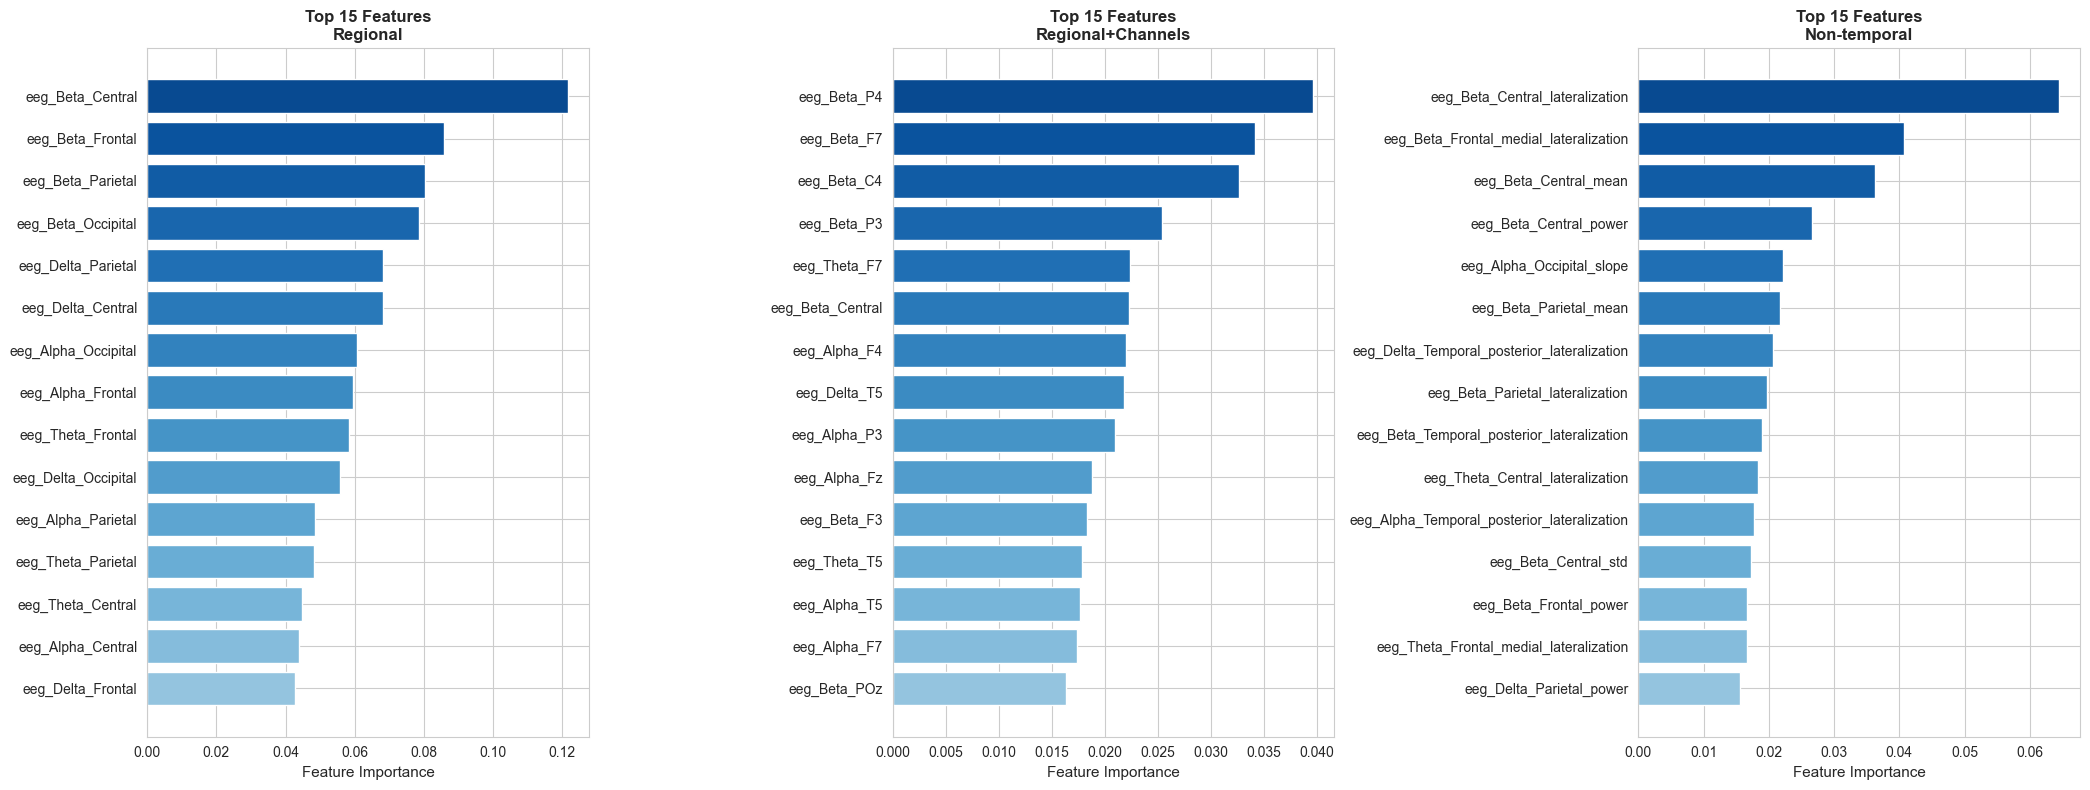

In [14]:
# Plot top features for each EEG set
n_top = 15
n_sets = len(eeg_only_results)

fig, axes = plt.subplots(1, n_sets, figsize=(7*n_sets, 8))
if n_sets == 1:
    axes = [axes]

for idx, (name, result) in enumerate(eeg_only_results.items()):
    ax = axes[idx]
    top_features = result['feature_importances'].head(n_top)
    
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_features)))
    ax.barh(range(len(top_features)), top_features['Importance'].values[::-1], color=colors)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['Feature'].values[::-1])
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top {n_top} Features\n{name}', fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Summary

In [15]:
print(f"\n{'='*70}")
print(f"SUMMARY: EEG FEATURE COMPARISON ({TIMEFRAME})")
print(f"{'='*70}")

# EEG-only performance
print(f"\n1. EEG-ONLY PERFORMANCE:")
for name, result in eeg_only_results.items():
    print(f"   {name:20s}: Acc={result['accuracy']:.3f} ± {result['accuracy_sem']:.3f}")

# Multimodal performance
print(f"\n2. MULTIMODAL FUSION PERFORMANCE (Weighted):")
for eeg_name, result in fusion_results.items():
    acc = result['results_weighted']['accuracy_mean']
    sem = result['results_weighted']['accuracy_sem']
    print(f"   {eeg_name:20s}: Acc={acc:.3f} ± {sem:.3f}")

# EEG contribution
print(f"\n3. EEG MODALITY CONTRIBUTION:")
for _, row in eeg_weights.iterrows():
    print(f"   {row['EEG Features']:20s}: {row['Weight']:.1f}%")

# Best configurations
print(f"\n4. BEST CONFIGURATIONS:")
print(f"   Best EEG-only: {best_eeg['Feature Set']} (Acc={best_eeg['Accuracy']:.3f})")
print(f"   Best Multimodal: {best_multi['EEG Features']} + {best_multi['Method']} (Acc={best_multi['Accuracy']:.3f})")
print(f"   Highest EEG Contribution: {eeg_weights.iloc[0]['EEG Features']} ({eeg_weights.iloc[0]['Weight']:.1f}%)")

print(f"\n{'='*70}")


SUMMARY: EEG FEATURE COMPARISON (PRE)

1. EEG-ONLY PERFORMANCE:
   Regional            : Acc=0.517 ± 0.016
   Regional+Channels   : Acc=0.507 ± 0.019
   Non-temporal        : Acc=0.490 ± 0.017

2. MULTIMODAL FUSION PERFORMANCE (Weighted):
   Regional            : Acc=0.698 ± 0.015
   Regional+Channels   : Acc=0.699 ± 0.015
   Non-temporal        : Acc=0.698 ± 0.015

3. EEG MODALITY CONTRIBUTION:
   Regional+Channels   : 2.8%
   Non-temporal        : 1.3%
   Regional            : 1.1%

4. BEST CONFIGURATIONS:
   Best EEG-only: Regional (Acc=0.517)
   Best Multimodal: Regional+Channels + Weighted (Acc=0.699)
   Highest EEG Contribution: Regional+Channels (2.8%)



## 10. Save Results

In [16]:
# Save all results
output_dir = f'../../data/results/fusion_models_eeg_{TIMEFRAME}'
Path(output_dir).mkdir(parents=True, exist_ok=True)

# 1. EEG-only comparison
save_results(eeg_only_df, f'{output_dir}/eeg_feature_set_comparison_single_modality.csv')

# 2. Multimodal fusion comparison
save_results(multimodal_df, f'{output_dir}/eeg_feature_set_comparison_multimodal.csv')

# 3. Modality weights
save_results(weights_df, f'{output_dir}/eeg_modality_weights_by_feature_set.csv')

# 4. Feature importances for each set
for name, result in eeg_only_results.items():
    safe_name = name.replace('+', '_').replace(' ', '_').replace('-', '_').lower()
    result['feature_importances'].to_csv(
        f'{output_dir}/eeg_feature_importances_{safe_name}.csv',
        index=False
    )
    print(f"✓ Saved {name} feature importances")

# 5. Subject-level accuracies
for eeg_name, result in fusion_results.items():
    safe_name = eeg_name.replace('+', '_').replace(' ', '_').replace('-', '_').lower()
    subject_df = pd.DataFrame({
        'subject_id': list(result['results_weighted']['subject_accs'].keys()),
        'accuracy': list(result['results_weighted']['subject_accs'].values())
    })
    save_results(subject_df, f'{output_dir}/multimodal_{safe_name}_subject_accuracies.csv')

print(f"\n✓ All results saved to: {output_dir}/")

✓ Saved results to: ../../data/results/fusion_models_eeg_PRE/eeg_feature_set_comparison_single_modality.csv
✓ Saved results to: ../../data/results/fusion_models_eeg_PRE/eeg_feature_set_comparison_multimodal.csv
✓ Saved results to: ../../data/results/fusion_models_eeg_PRE/eeg_modality_weights_by_feature_set.csv
✓ Saved Regional feature importances
✓ Saved Regional+Channels feature importances
✓ Saved Non-temporal feature importances
✓ Saved results to: ../../data/results/fusion_models_eeg_PRE/multimodal_regional_subject_accuracies.csv
✓ Saved results to: ../../data/results/fusion_models_eeg_PRE/multimodal_regional_channels_subject_accuracies.csv
✓ Saved results to: ../../data/results/fusion_models_eeg_PRE/multimodal_non_temporal_subject_accuracies.csv

✓ All results saved to: ../../data/results/fusion_models_eeg_PRE/
